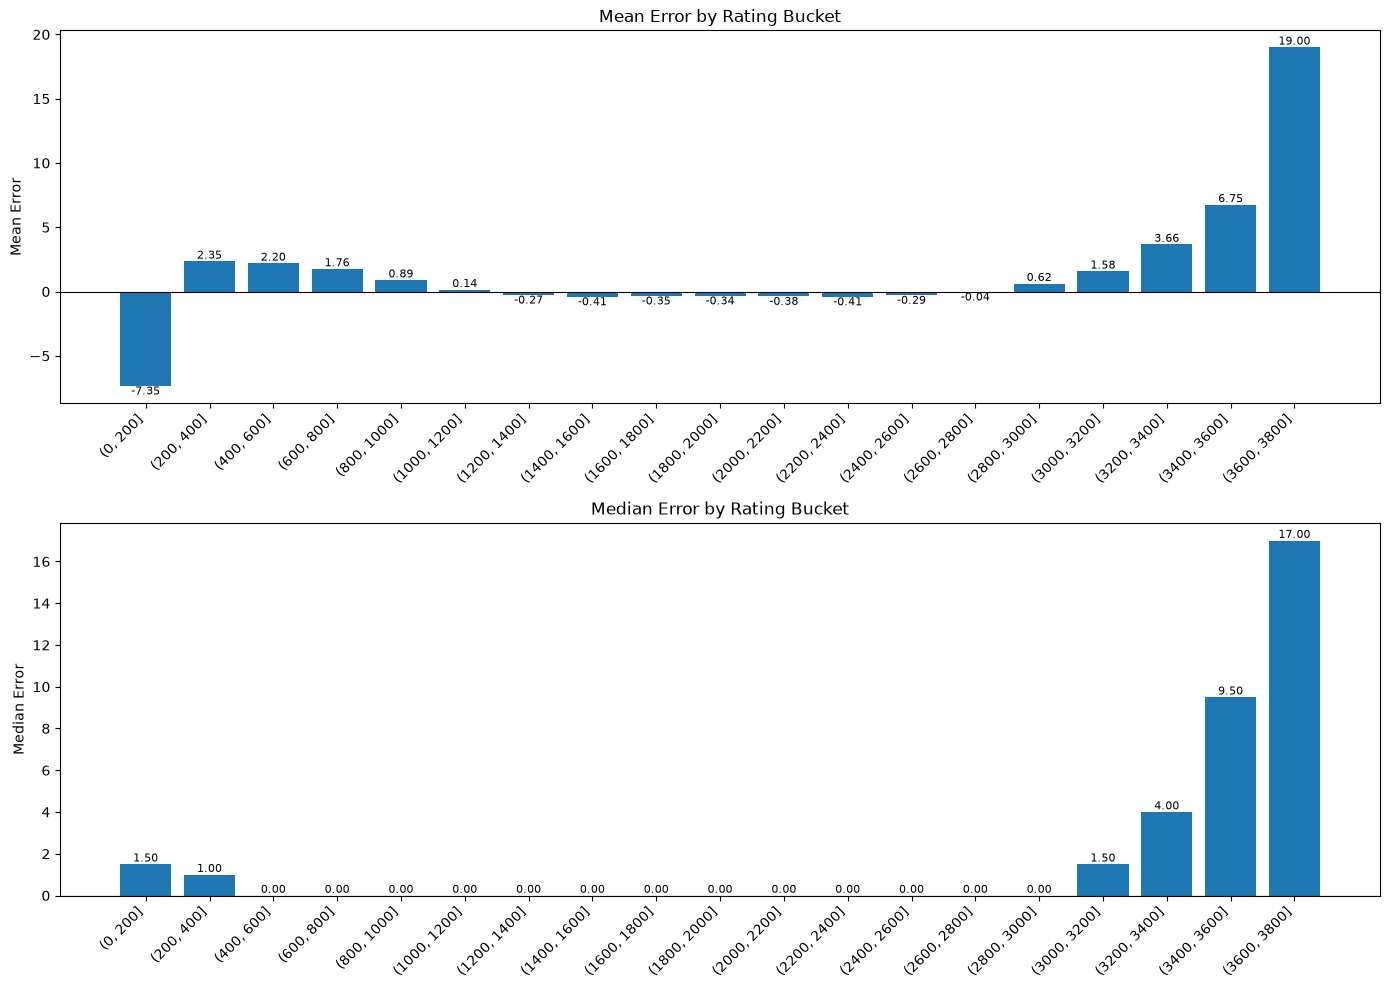

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from utils import PROJECT_ROOT

df = pd.read_csv(str(PROJECT_ROOT)+"/data/validation/naive/per_participant.csv")
df["rating_bin"] = pd.cut(df["old_rating"], bins=range(0, 4200, 200))

mean_err = df.groupby("rating_bin", observed=True)["error"].mean()
mean_abs_err = df.groupby("rating_bin", observed=True)["abs_error"].mean()
median_err = df.groupby("rating_bin", observed=True)["error"].median()
median_abs_err = df.groupby("rating_bin", observed=True)["abs_error"].median()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

bars = ax1.bar(range(len(mean_err)), mean_err.values)
ax1.set_xticks(range(len(mean_err)))
ax1.set_xticklabels(mean_err.index, rotation=45, ha="right")
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_title("Mean Error by Rating Bucket")
ax1.set_ylabel("Mean Error")
for bar, val in zip(bars, mean_err.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{val:.2f}", ha="center", va="bottom" if val >= 0 else "top", fontsize=8)

bars = ax2.bar(range(len(median_err)), median_err.values)
ax2.set_xticks(range(len(median_err)))
ax2.set_xticklabels(median_err.index, rotation=45, ha="right")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Median Error by Rating Bucket")
ax2.set_ylabel("Median Error")
for bar, val in zip(bars, median_err.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{val:.2f}", ha="center", va="bottom" if val >= 0 else "top", fontsize=8)

fig.tight_layout()
plt.show()


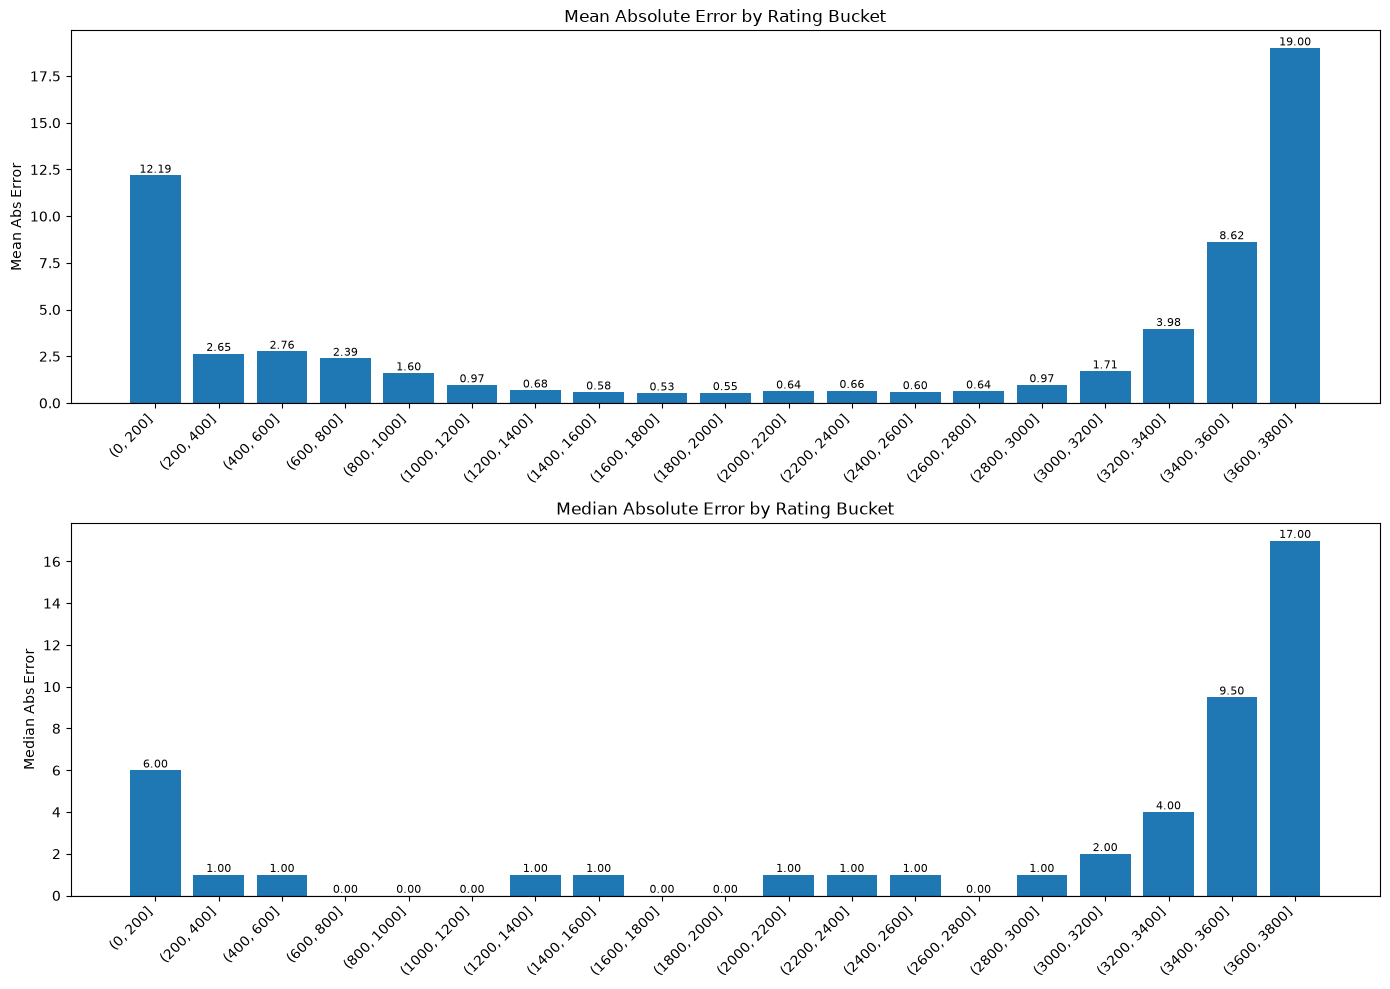

In [2]:
fig, (ax3, ax4) = plt.subplots(2, 1, figsize=(14, 10))

bars = ax3.bar(range(len(mean_abs_err)), mean_abs_err.values)
ax3.set_xticks(range(len(mean_abs_err)))
ax3.set_xticklabels(mean_abs_err.index, rotation=45, ha="right")
ax3.axhline(0, color="black", linewidth=0.8)
ax3.set_title("Mean Absolute Error by Rating Bucket")
ax3.set_ylabel("Mean Abs Error")
for bar, val in zip(bars, mean_abs_err.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{val:.2f}", ha="center", va="bottom", fontsize=8)

bars = ax4.bar(range(len(median_abs_err)), median_abs_err.values)
ax4.set_xticks(range(len(median_abs_err)))
ax4.set_xticklabels(median_abs_err.index, rotation=45, ha="right")
ax4.axhline(0, color="black", linewidth=0.8)
ax4.set_title("Median Absolute Error by Rating Bucket")
ax4.set_ylabel("Median Abs Error")
for bar, val in zip(bars, median_abs_err.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{val:.2f}", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
plt.show()


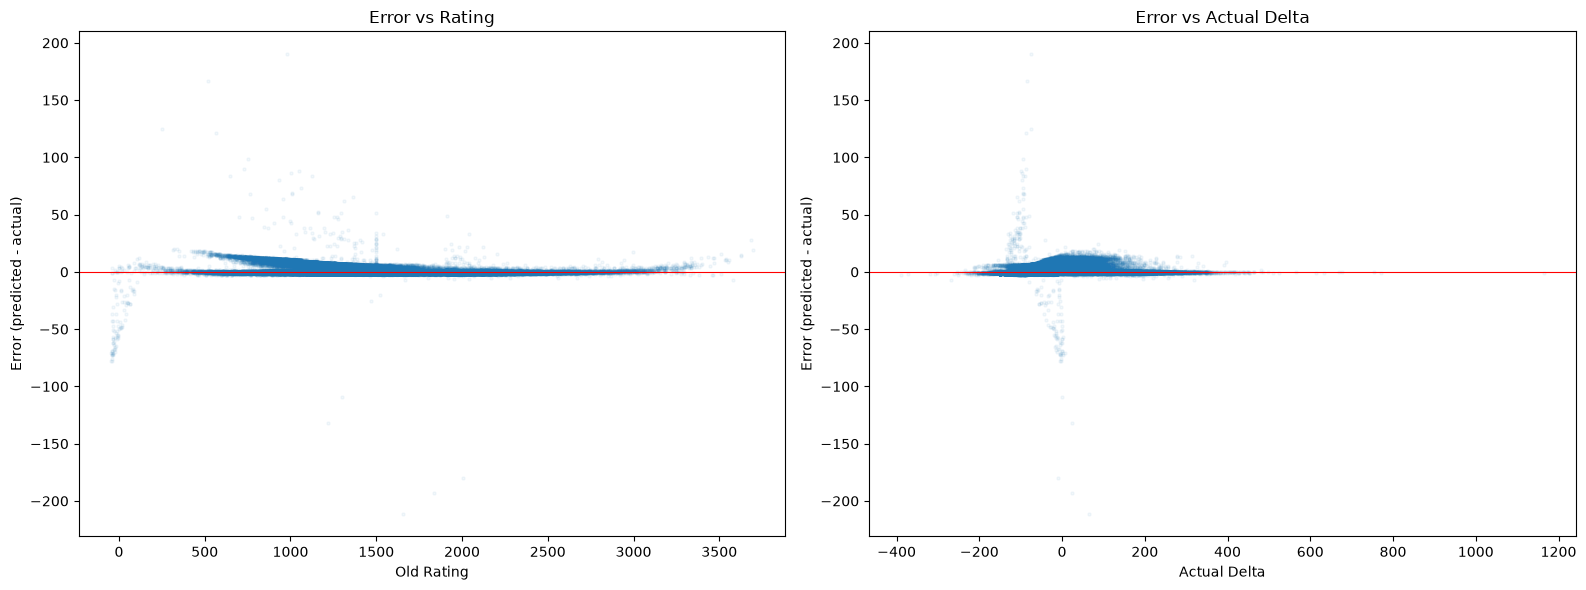

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(df["old_rating"], df["error"], alpha=0.05, s=5)
ax1.axhline(0, color="red", linewidth=0.8)
ax1.set_xlabel("Old Rating")
ax1.set_ylabel("Error (predicted - actual)")
ax1.set_title("Error vs Rating")

ax2.scatter(df["actual_delta"], df["error"], alpha=0.05, s=5)
ax2.axhline(0, color="red", linewidth=0.8)
ax2.set_xlabel("Actual Delta")
ax2.set_ylabel("Error (predicted - actual)")
ax2.set_title("Error vs Actual Delta")

fig.tight_layout()
plt.show()


Selected contest IDs: [1137 1016 1155]


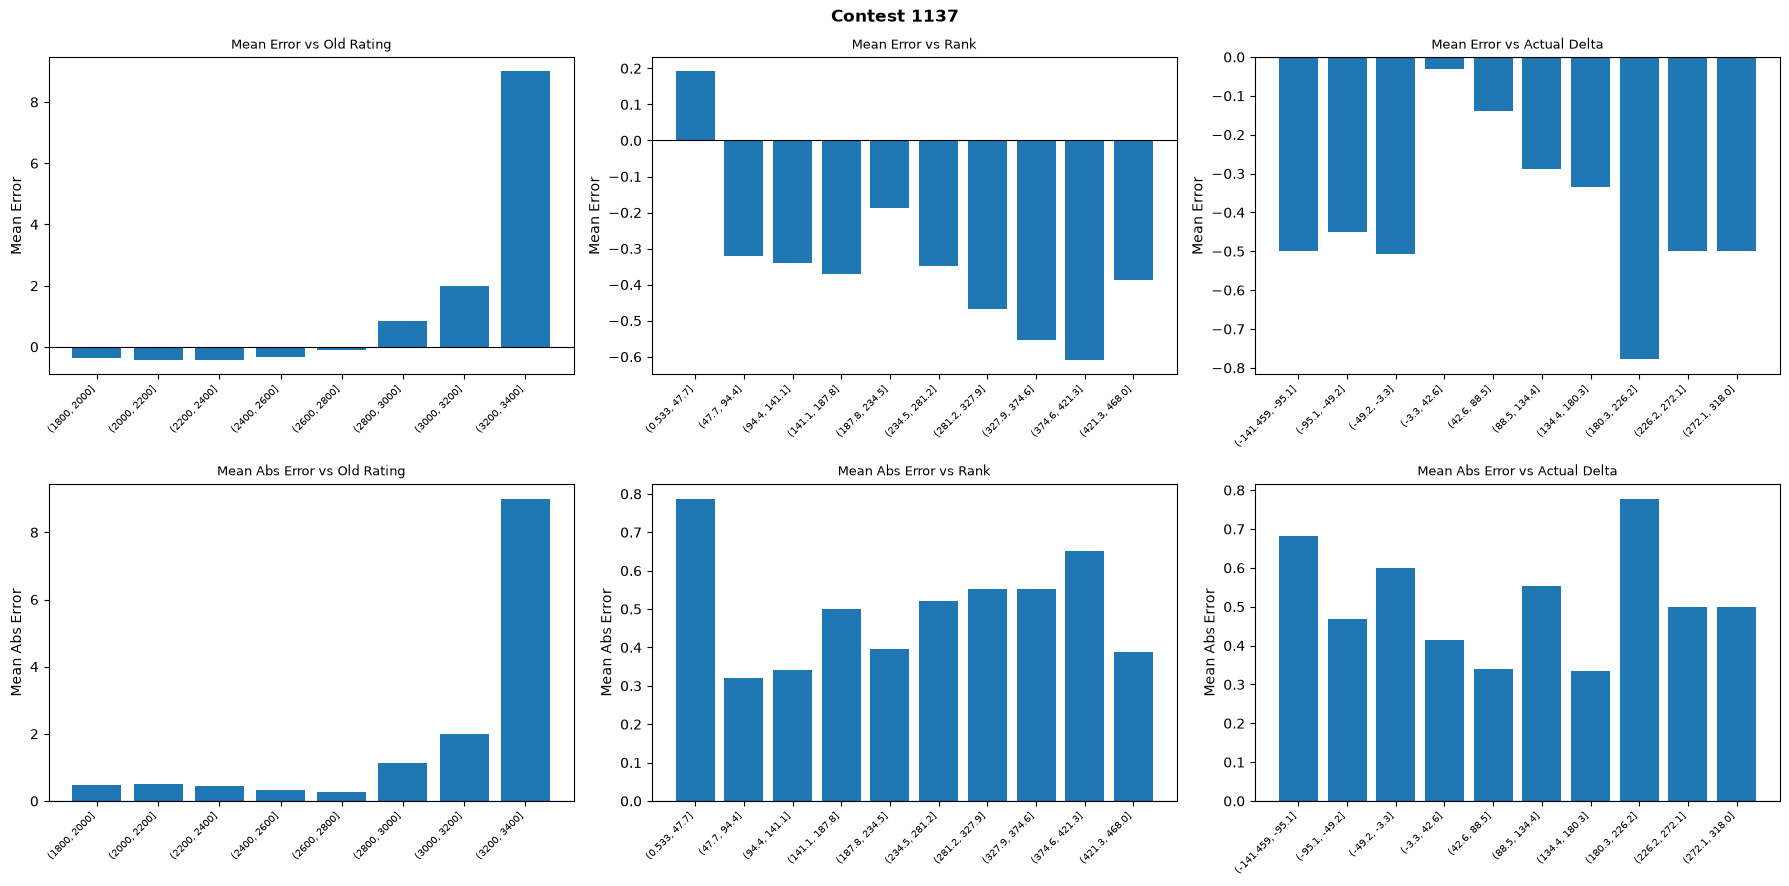

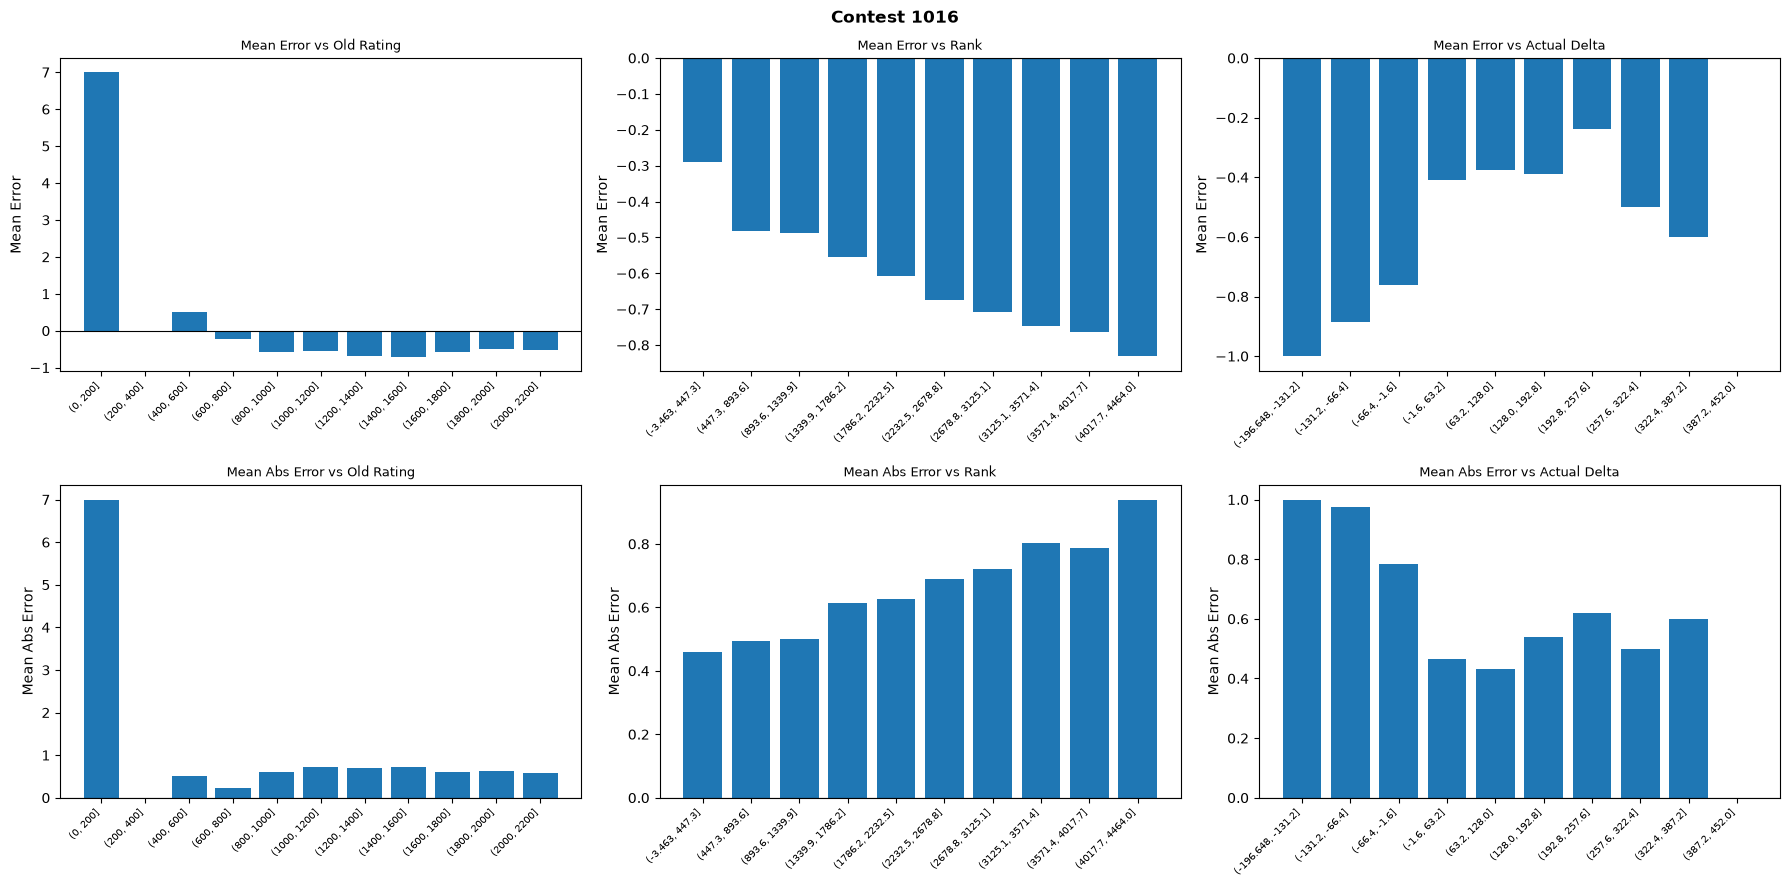

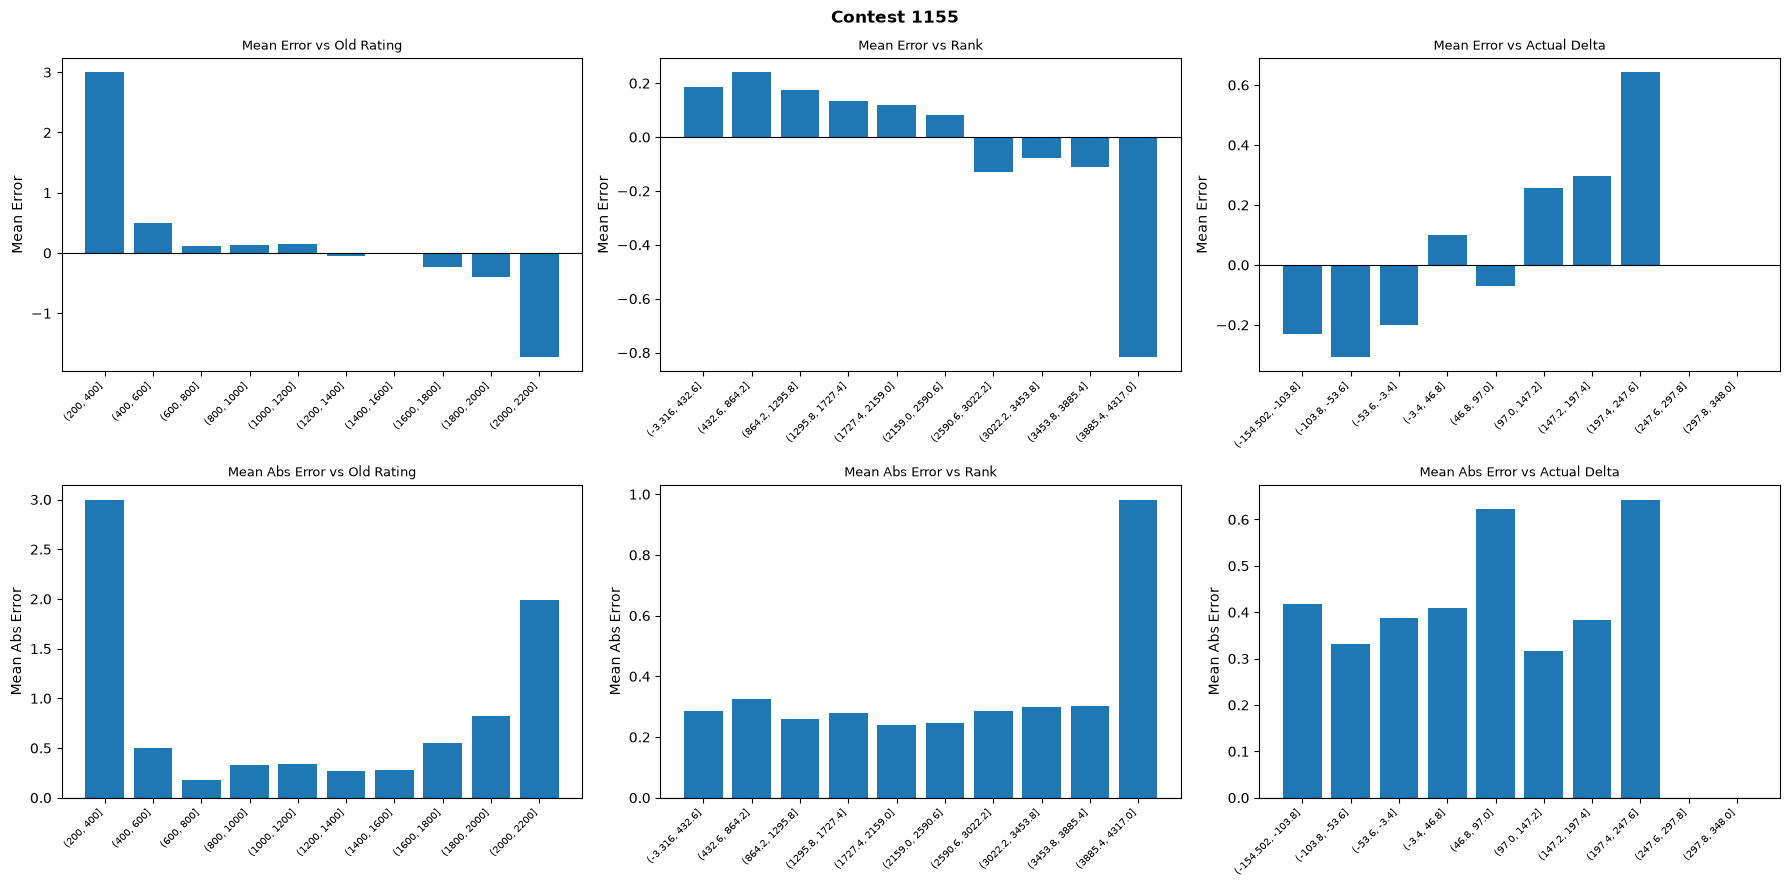

In [4]:
import numpy as np

available = df[(df["contest_id"] >= 1000) & (df["contest_id"] < 1200)]["contest_id"].unique()
rng = np.random.default_rng(seed=42)
selected = rng.choice(available, size=3, replace=False)
print("Selected contest IDs:", selected)

for cid in selected:
    sub = df[df["contest_id"] == cid].copy()
    sub["rating_bin"] = pd.cut(sub["old_rating"], bins=range(0, 4200, 200))
    sub["rank_bin"]   = pd.cut(sub["rank"], bins=10)
    sub["delta_bin"]  = pd.cut(sub["actual_delta"], bins=10)

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    fig.suptitle(f"Contest {cid}", fontsize=12, fontweight="bold")

    for col, (bin_col, label) in enumerate(zip(
        ["rating_bin", "rank_bin", "delta_bin"],
        ["Old Rating", "Rank", "Actual Delta"],
    )):
        for row, (metric, title) in enumerate(zip(["error", "abs_error"], ["Mean Error", "Mean Abs Error"])):
            ax = axes[row, col]
            grouped = sub.groupby(bin_col, observed=True)[metric].mean()
            ax.bar(range(len(grouped)), grouped.values)
            ax.set_xticks(range(len(grouped)))
            ax.set_xticklabels(grouped.index, rotation=45, ha="right", fontsize=7)
            ax.axhline(0, color="black", linewidth=0.8)
            ax.set_title(f"{title} vs {label}", fontsize=9)
            ax.set_ylabel(title)

    fig.tight_layout()
    plt.show()


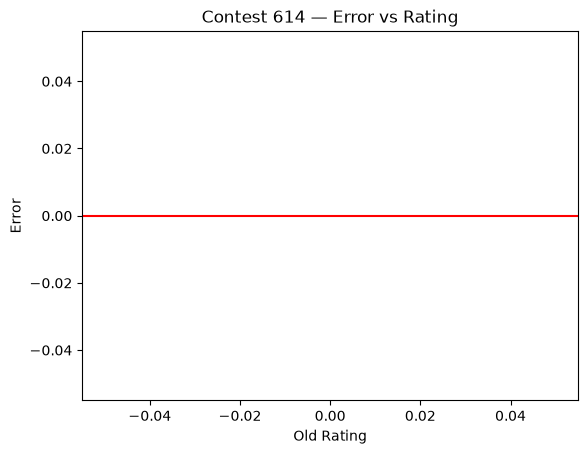

In [5]:
df614 = df[df["contest_id"] == 614]
plt.scatter(df614["old_rating"], df614["error"], alpha=0.4, s=10)
plt.axhline(0, color="red")
plt.xlabel("Old Rating")
plt.ylabel("Error")
plt.title("Contest 614 — Error vs Rating")
plt.show()
